Import the libraries.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

Read the data.

In [ ]:
df = pd.read_csv('Datasets/titanic_dataset.csv', usecols=['Age','Fare', 'Survived'])
df.sample(5)

,Survived,Age,Fare
133,1,29.0,26.0000
331,0,45.5,28.5000
450,0,36.0,27.7500
22,1,15.0,8.0292
86,0,16.0,34.3750


In [ ]:
df.dropna(inplace=True)
df.shape

(714, 3)

Split the data into train and test and train the model by Decision Tree Classifier.

In [ ]:
x = df.iloc[:,1:]
y = df.iloc[:,0]    

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
clf = DecisionTreeClassifier()
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
accuracy_score(y_test, y_pred)

0.6223776223776224

Find the cross validation score.

In [ ]:
np.mean(cross_val_score(clf,x,y,scoring='accuracy',cv=10))

np.float64(0.6289319248826291)

Use binning technique with quantile as strategy.

In [ ]:
kbin_age = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile',quantile_method='averaged_inverted_cdf')
kbin_fare = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile',quantile_method='averaged_inverted_cdf')

Column transformer for both the columns.

In [ ]:
trf = ColumnTransformer([
    ('first', kbin_age, [0]),
    ('second', kbin_fare, [1])
])


In [ ]:
x_train_trf = trf.fit_transform(x_train)
x_test_trf = trf.transform(x_test)

In [ ]:
trf.named_transformers_['first'].n_bins_

array([10])

Compare the values before and after binning and corresponding bin in which they lie.

In [ ]:
output = pd.DataFrame({
    'age':x_train['Age'],
    'age_trf':x_train_trf[:,0],
    'fare':x_train['Fare'],
    'fare_trf':x_train_trf[:,1]
})
output['age_labels'] = pd.cut(x=x_train['Age'],bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=x_train['Fare'],bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
864,24.0,3.0,13.0000,4.0,"(22.0, 25.0]","(9.225, 13.0]"
382,32.0,6.0,7.9250,2.0,"(28.5, 32.0]","(7.896, 9.225]"
841,16.0,1.0,10.5000,3.0,"(14.0, 19.0]","(9.225, 13.0]"
696,44.0,8.0,8.0500,2.0,"(42.0, 50.0]","(7.896, 9.225]"
74,32.0,6.0,56.4958,8.0,"(28.5, 32.0]","(51.479, 82.171]"


Train the model using Decision Tree and find the accuracy score.

In [ ]:
clf = DecisionTreeClassifier()
clf.fit(x_train_trf, y_train)
y_pred_trf = clf.predict(x_test_trf)
accuracy_score(y_test, y_pred_trf)

0.6223776223776224

In [ ]:
x_tnf = trf.fit_transform(x)    
np.mean(cross_val_score(clf,x,y,scoring='accuracy',cv=10))

np.float64(0.6344874804381846)

A function for discretization of data with input as bins and the strategy and it will plot the before and after hitograms of the data.

In [ ]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])

    x_trf = trf.fit_transform(x)

    print(np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(x_trf[:,0],color='red')
    plt.title("After")

    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(x_trf[:,1],color='red')
    plt.title("After")

    plt.show()

Some examples.

/home/hardik/.local/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/home/hardik/.local/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


0.6344874804381846


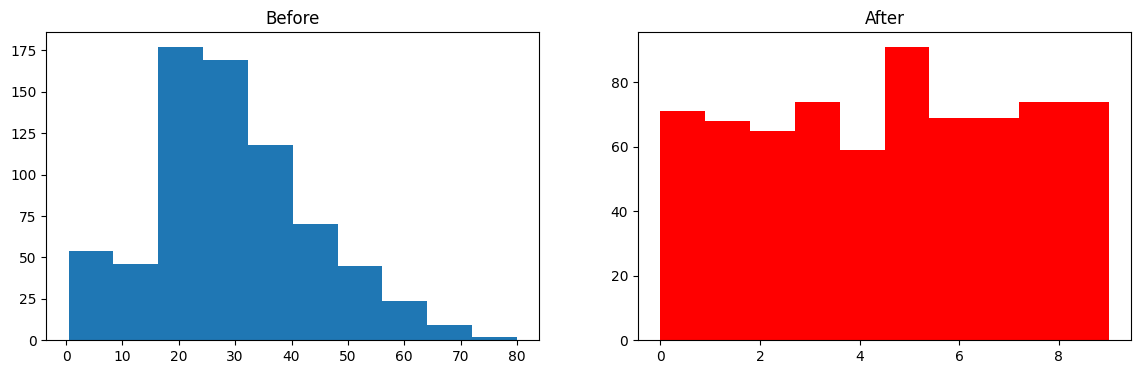

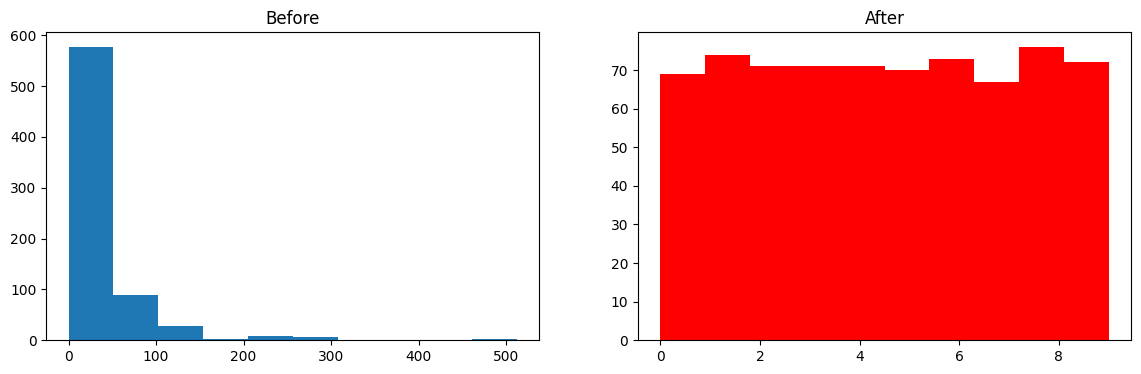

In [ ]:
discretize(10,'quantile')

Binarization of data.

In [ ]:
df2 = pd.read_csv('Datasets/titanic_dataset.csv', usecols=['Age','Fare', 'SibSp', 'Parch', 'Survived'])
df2.sample(5)

,Survived,Age,SibSp,Parch,Fare
473,1,23.0,0,0,13.7917
720,1,6.0,0,1,33.0000
695,0,52.0,0,0,13.5000
367,1,NaN,0,0,7.2292
647,1,56.0,0,0,35.5000


Create a new column.

In [ ]:
df2['Family'] = df2['SibSp'] + df2['Parch']
df_new = df2.drop(columns=['SibSp', 'Parch'], inplace=False)
df_new.sample(5)

,Survived,Age,Fare,Family
90,0,29.0,8.0500,0
876,0,20.0,9.8458,0
865,1,42.0,13.0000,0
181,0,NaN,15.0500,0
161,1,40.0,15.7500,0


Split the data and train the model.

In [ ]:
x = df_new.drop(columns=['Survived'])
y = df_new['Survived']
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
clf = DecisionTreeClassifier()
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
accuracy_score(y_test, y_pred)

0.659217877094972

Find the cross validation score.

In [ ]:
np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy'))

np.float64(0.6396878901373283)

Binarization of the data.

In [ ]:
from sklearn.preprocessing import Binarizer
trf = ColumnTransformer([
    ('bin',Binarizer(copy=False),['Family'])
],remainder='passthrough')

x_train_trf = trf.fit_transform(x_train)
x_test_trf = trf.transform(x_test)

Convert the numpy array into dataframes.

In [ ]:
pd.DataFrame(x_train_trf,columns=['Family','Age','Fare'])

,Family,Age,Fare
0,0.0,45.5,28.5000
1,0.0,23.0,13.0000
2,0.0,32.0,7.9250
3,1.0,26.0,7.8542
4,1.0,6.0,31.2750
...,...,...,...
707,0.0,21.0,7.6500
708,0.0,NaN,31.0000
709,1.0,41.0,14.1083
710,1.0,14.0,120.0000


Train the model.

In [ ]:
clf = DecisionTreeClassifier()
clf.fit(x_train_trf,y_train)
y_pred2 = clf.predict(x_test_trf)

accuracy_score(y_test,y_pred2)

0.6424581005586593

Find the cross validation score.

In [ ]:
x_trf = trf.fit_transform(x)
np.mean(cross_val_score(DecisionTreeClassifier(),x_trf,y,cv=10,scoring='accuracy'))

np.float64(0.6532209737827716)